#  Heart Disease Prediction
## Internship Task 3
## Author: Ahmad Afzaal

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [33]:
df = pd.read_csv("heart.csv", sep="\t")
df.head()

,Gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Heart_stroke
0,Male,39,postgraduate,0,0.0,0.0,no,0,0,195.0,106.0,70.0,26.97,80.0,77.0,No
1,Female,46,primaryschool,0,0.0,0.0,no,0,0,250.0,121.0,81.0,28.73,95.0,76.0,No
2,Male,48,uneducated,1,20.0,0.0,no,0,0,245.0,127.5,80.0,25.34,75.0,70.0,No
3,Female,61,graduate,1,30.0,0.0,no,1,0,225.0,150.0,95.0,28.58,65.0,103.0,yes
4,Female,46,graduate,1,23.0,0.0,no,0,0,285.0,130.0,84.0,23.10,85.0,85.0,No


In [34]:
df = df.dropna()

In [35]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["prevalentStroke"] = df["prevalentStroke"].map({"yes": 1, "no": 0})
df["Heart_stroke"] = df["Heart_stroke"].map({"yes": 1, "No": 0})

le = LabelEncoder()
df["education"] = le.fit_transform(df["education"])

In [36]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(3656, 16)
<class 'pandas.DataFrame'>
Index: 3656 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           3656 non-null   int64  
 1   age              3656 non-null   int64  
 2   education        3656 non-null   int64  
 3   currentSmoker    3656 non-null   int64  
 4   cigsPerDay       3656 non-null   float64
 5   BPMeds           3656 non-null   float64
 6   prevalentStroke  3656 non-null   int64  
 7   prevalentHyp     3656 non-null   int64  
 8   diabetes         3656 non-null   int64  
 9   totChol          3656 non-null   float64
 10  sysBP            3656 non-null   float64
 11  diaBP            3656 non-null   float64
 12  BMI              3656 non-null   float64
 13  heartRate        3656 non-null   float64
 14  glucose          3656 non-null   float64
 15  Heart_stroke     3656 non-null   int64  
dtypes: float64(8), int64(8)
memory usage: 485.6 KB
None
Gender       

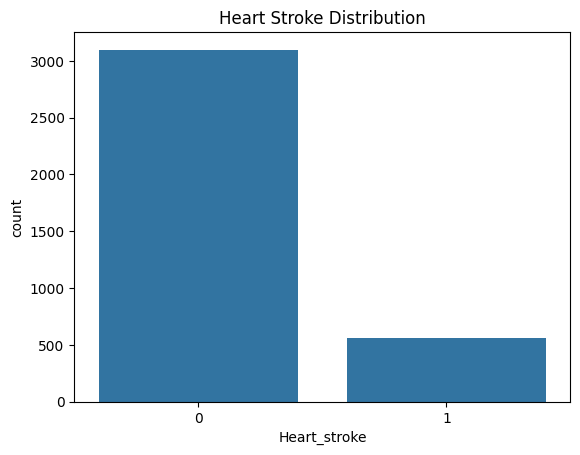

In [37]:
sns.countplot(x="Heart_stroke", data=df)
plt.title("Heart Stroke Distribution")
plt.show()

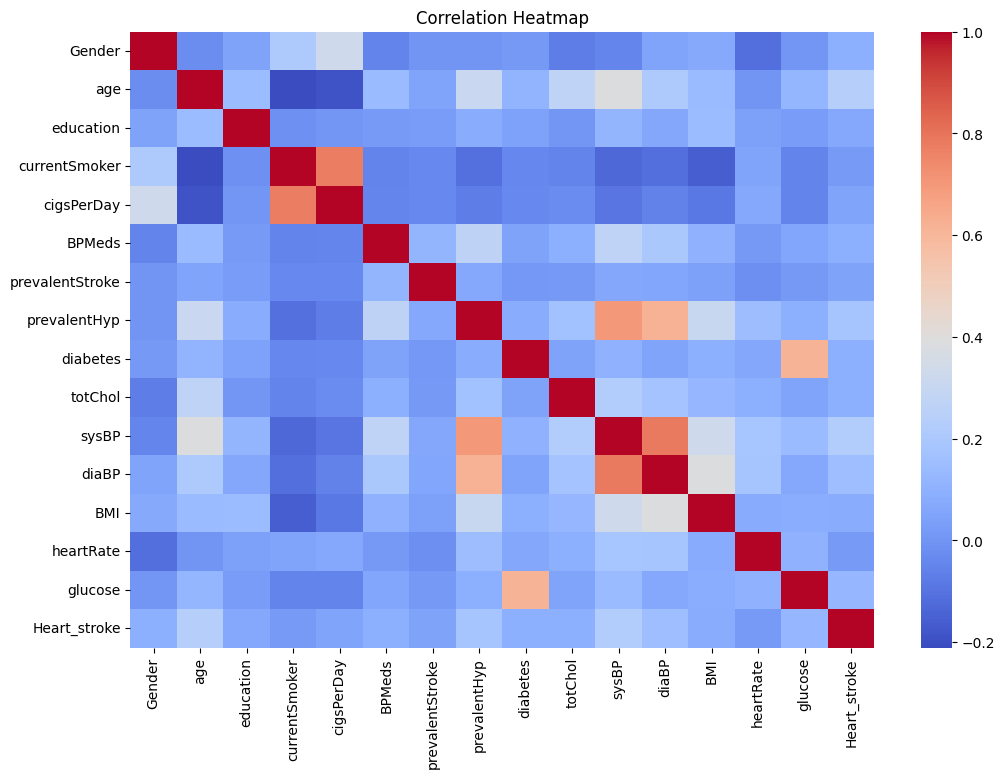

In [38]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [39]:
X = df.drop("Heart_stroke", axis=1)
y = df["Heart_stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print("-"*30)

Logistic Regression
Accuracy: 0.8387978142076503
------------------------------
Random Forest
Accuracy: 0.8387978142076503
------------------------------


In [42]:
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8387978142076503


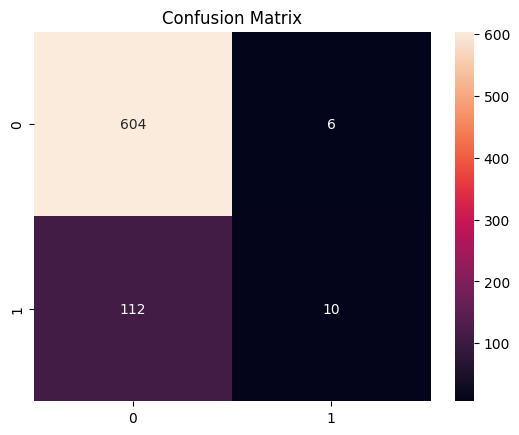

In [44]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.99      0.91       610
           1       0.62      0.08      0.14       122

    accuracy                           0.84       732
   macro avg       0.73      0.54      0.53       732
weighted avg       0.81      0.84      0.78       732



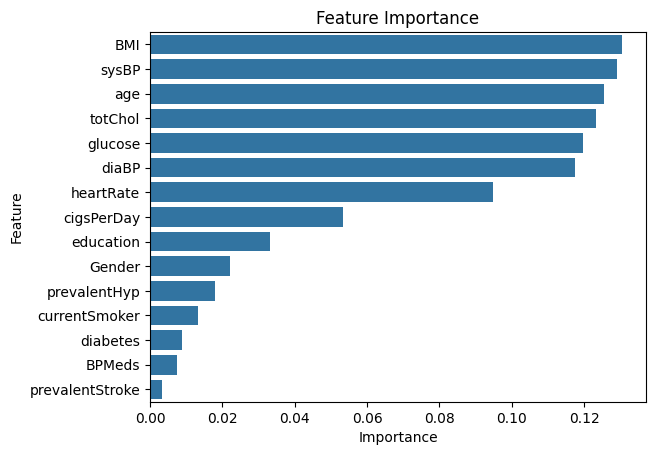

In [46]:
importances = best_model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Feature Importance")
plt.show()

## 📌 Insights

- Dataset contains ~4200 records
- Random Forest performed better than Logistic Regression
- Most important features:
  - age
  - sysBP
  - glucose
  - cholesterol
- Model can help in early heart stroke risk detection